# Experiment 01 — Whole-document prompt vs batched inference

**Question:** Does sending all blocks in one API call (whole-doc) outperform sending 10 blocks at a time (batched) with a sliding context window?

| Variant | Strategy | Model | Data |
|---|---|---|---|
| `llama3.3 batch` | 10 blocks/request · 3-block context | llama3.3:70b via Ollama | 10/10 samples |
| `llama3.1 batch` | 10 blocks/request · 3-block context | llama3.1:8b via Ollama | 10/10 samples |
| `claude batch` | 10 blocks/request · 3-block context | claude-opus-4-8 via Anthropic | 10/10 samples |
| `claude whole-doc` | All blocks in 1 request · full context | claude-opus-4-8 via Anthropic | 10/10 samples |

> Llama whole-doc variants are not yet generated — run `python run_wholedoc_ollama.py --model llama3.3:70b` to add them.

**Sections:**
1. Overall accuracy — all variants across all 10 samples
2. Per-sample accuracy — bar chart + heatmap
3. F1 per label — where each variant struggles
4. Claude batched vs whole-doc delta — core experiment
5. Block-level gained / lost — what whole-doc actually fixes
6. Summary

## Setup

In [1]:
import sys, json
sys.path.insert(0, "../..")

from evaluate import extract_gold, evaluate_sample, match, LABELS, SHORT, LLM_DIR, MANUAL_DIR
from collections import defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="ticks", palette="muted")
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#555",    "axes.linewidth": 0.8,
    "grid.color": "#ddd",        "grid.linewidth": 0.5,
    "text.color": "#111",        "axes.labelcolor": "#111",
    "xtick.color": "#111",       "ytick.color": "#111",
    "font.size": 11, "axes.titlesize": 13, "axes.labelsize": 11,
    "xtick.labelsize": 10,       "ytick.labelsize": 10,
    "legend.fontsize": 10,       "legend.frameon": True,
    "figure.dpi": 120,
})

# ── Variant registry ───────────────────────────────────────────────────────────
# (tag, display color, hatch for whole-doc)
VARIANTS = {
    "llama3.3 batch":   ("llama3.3-70b",            "#1d4ed8", None),
    "llama3.1 batch":   ("llama3.1-8b",             "#0369a1", None),
    "claude batch":     ("claude-opus-4-8",          "#7c3aed", None),
    "claude whole-doc": ("claude-opus-4-8-wholedoc", "#c084fc", "//"),
}

def _snum(p):
    stem = p.stem if hasattr(p, "stem") else str(p)
    return int(stem.replace("_dmp", "").replace("sample", ""))

SAMPLES = sorted(MANUAL_DIR.glob("*_dmp.json"), key=_snum)
SNAMES  = [mp.stem.replace("_dmp", "") for mp in SAMPLES]

def _f1(conf, lbl):
    tp = conf.get(lbl, {}).get(lbl, 0)
    fp = sum(conf.get(o, {}).get(lbl, 0) for o in LABELS if o != lbl)
    fn = sum(v for p, v in conf.get(lbl, {}).items() if p != lbl)
    p_ = tp / (tp + fp) if (tp + fp) else 0.
    r_ = tp / (tp + fn) if (tp + fn) else 0.
    return 2 * p_ * r_ / (p_ + r_) if (p_ + r_) else 0.

def load_variant(tag):
    """Load all samples for a tag. Returns (per_sample_df, conf_all) or (None, None)."""
    rows, conf = [], defaultdict(lambda: defaultdict(int))
    for mp in SAMPLES:
        stem = mp.stem.replace("_dmp", "")
        pp   = LLM_DIR / f"{stem}_{tag}.json"
        if not pp.exists(): continue
        gold = extract_gold(mp)
        c    = evaluate_sample(pp, gold)
        for tl, preds in c.items():
            for pl, cnt in preds.items():
                conf[tl][pl] += cnt
        tp = sum(c.get(l, {}).get(l, 0) for l in LABELS)
        n  = sum(sum(v.values()) for v in c.values())
        rows.append({"sample": stem, "total": n, "correct": tp,
                     "errors": n - tp, "accuracy": tp / n if n else 0})
    return (pd.DataFrame(rows), conf) if rows else (None, None)

DATA = {name: load_variant(tag) for name, (tag, _, _) in VARIANTS.items()}
ACTIVE = {n: d for n, d in DATA.items() if d[0] is not None}

print(f"  {'Variant':<22}  {'Samples':>7}  {'Correct':>7}  {'Total':>6}  {'Accuracy':>9}")
print("  " + "-" * 58)
for name, (df, _) in DATA.items():
    if df is None: print(f"  {name:<22}  no data (files not yet generated)"); continue
    tc, tn = int(df["correct"].sum()), int(df["total"].sum())
    print(f"  {name:<22}  {len(df):>7}  {tc:>7}  {tn:>6}  {tc/tn*100:>8.1f}%")

  Variant                 Samples  Correct   Total   Accuracy
  ----------------------------------------------------------
  llama3.3 batch               10      697     741      94.1%
  llama3.1 batch               10      499     741      67.3%
  claude batch                 10      703     741      94.9%
  claude whole-doc             10      718     741      96.9%


## 1 — Overall accuracy (all 10 samples)

Per-sample accuracy for every available variant. The `delta` column shows how much whole-doc changes accuracy vs claude batched (positive = improvement).

In [2]:
rows = []
for sname in SNAMES:
    row = {"sample": sname}
    for vname, (df, _) in ACTIVE.items():
        sub = df[df["sample"] == sname]
        row[vname] = sub["accuracy"].values[0] * 100 if len(sub) else None
    rows.append(row)

tbl = pd.DataFrame(rows).set_index("sample")

if "claude batch" in tbl.columns and "claude whole-doc" in tbl.columns:
    tbl["Δ claude"] = tbl["claude whole-doc"] - tbl["claude batch"]

# Pretty-print
cols = list(ACTIVE.keys()) + (["Δ claude"] if "Δ claude" in tbl.columns else [])
hdr = f"  {'Sample':<12}" + "".join(f"  {c:>18}" for c in cols)
print(hdr)
print("  " + "-" * (12 + 20 * len(cols)))
for sname, r in tbl.iterrows():
    row_str = f"  {sname:<12}"
    for c in list(ACTIVE.keys()):
        val = r.get(c)
        row_str += f"  {val:>17.1f}%" if val is not None else f"  {'--':>17}"
    if "Δ claude" in tbl.columns:
        d = r["Δ claude"]
        row_str += f"  {'+' if d>=0 else ''}{d:>16.1f}%"
    print(row_str)

print("  " + "-" * (12 + 20 * len(cols)))
total_row = f"  {'OVERALL':<12}"
for name in ACTIVE:
    df, _ = ACTIVE[name]
    ov = df["correct"].sum() / df["total"].sum() * 100
    total_row += f"  {ov:>17.1f}%"
if "claude batch" in ACTIVE and "claude whole-doc" in ACTIVE:
    tb = ACTIVE["claude batch"][0]["correct"].sum()    / ACTIVE["claude batch"][0]["total"].sum()
    tw = ACTIVE["claude whole-doc"][0]["correct"].sum() / ACTIVE["claude whole-doc"][0]["total"].sum()
    od = (tw - tb) * 100
    total_row += f"  {'+' if od>=0 else ''}{od:>16.1f}%"
print(total_row)

  Sample            llama3.3 batch      llama3.1 batch        claude batch    claude whole-doc            Δ claude
  ----------------------------------------------------------------------------------------------------------------
  sample1                    97.4%               82.1%              100.0%              100.0%  +             0.0%
  sample2                    90.7%               59.9%               86.6%               96.5%  +             9.9%
  sample3                    98.6%               81.2%              100.0%              100.0%  +             0.0%
  sample4                   100.0%               65.4%              100.0%              100.0%  +             0.0%
  sample5                    91.9%               62.8%               93.0%               93.0%  +             0.0%
  sample6                    62.1%               55.2%               72.4%               65.5%              -6.9%
  sample7                    94.1%               82.4%               94.1%       

## 2 — Per-sample accuracy

Side-by-side bars for each sample, followed by a heatmap for a quick overview. Solid bars = batched, hatched (`//`) = whole-doc.

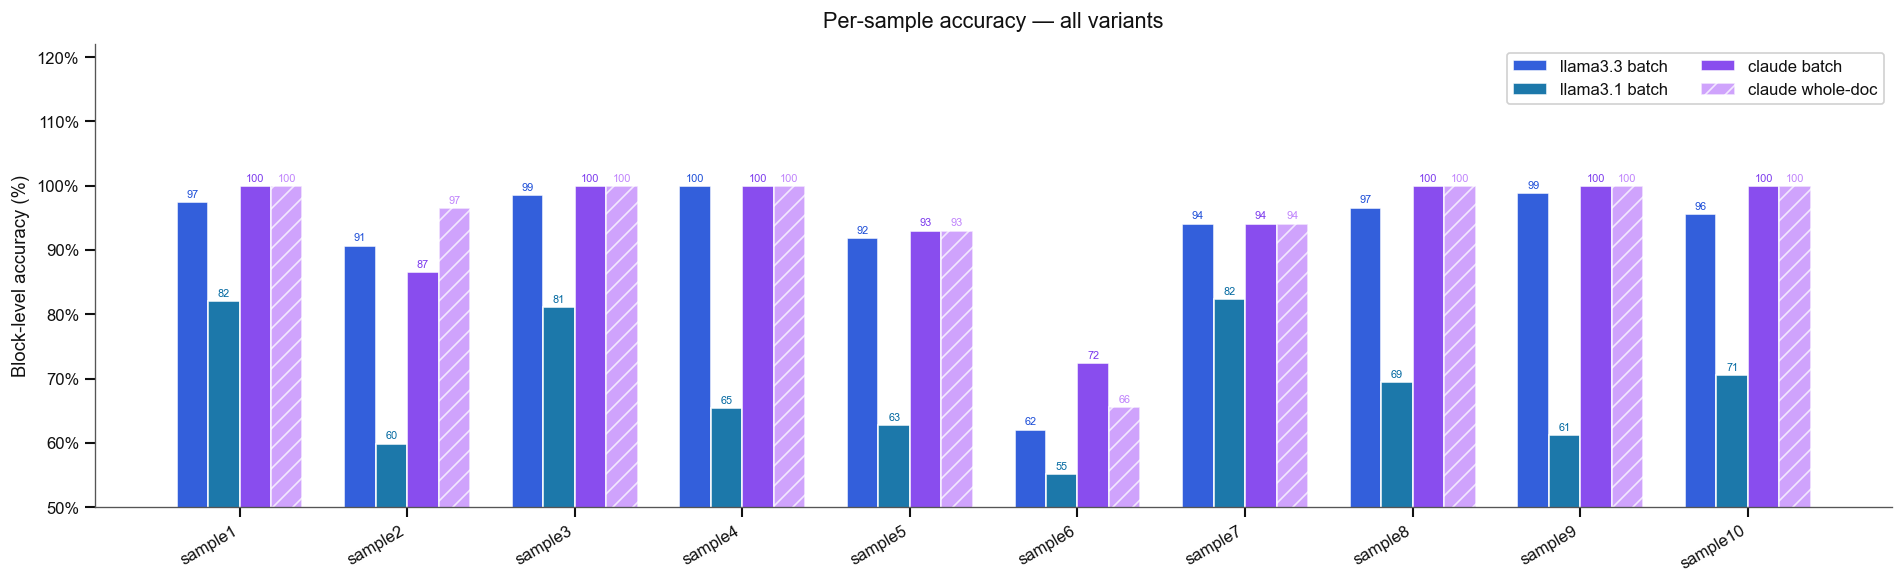

In [3]:
n_v = len(ACTIVE)
w   = 0.75 / n_v
x   = list(range(len(SNAMES)))

fig, ax = plt.subplots(figsize=(16, 5))
for i, (name, (df, _)) in enumerate(ACTIVE.items()):
    _, color, hatch = VARIANTS[name]
    alpha = 0.9 if hatch is None else 0.75
    vals  = [
        df[df["sample"] == s]["accuracy"].values[0] * 100
        if len(df[df["sample"] == s]) else 0
        for s in SNAMES
    ]
    offset = (i - n_v / 2 + 0.5) * w
    bars   = ax.bar(
        [xi + offset for xi in x], vals,
        width=w, label=name, color=color,
        edgecolor="white", alpha=alpha, hatch=hatch
    )
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                    f"{v:.0f}", ha="center", va="bottom", fontsize=6.5, color=color)

ax.set_xticks(x)
ax.set_xticklabels(SNAMES, rotation=30, ha="right")
ax.set_ylim(50, 122)
ax.set_ylabel("Block-level accuracy (%)")
ax.set_title("Per-sample accuracy — all variants", pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.legend(framealpha=0.9, ncol=2)
sns.despine()
plt.tight_layout()
plt.show()

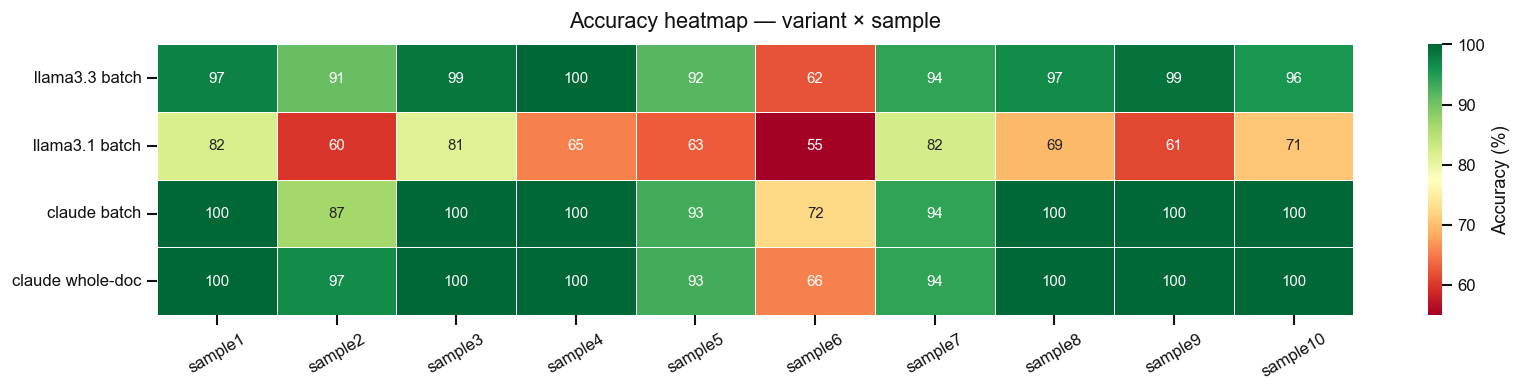

In [4]:
# Heatmap: variant (row) × sample (column)
hmap_data = []
for name, (df, _) in ACTIVE.items():
    row = [
        df[df["sample"] == s]["accuracy"].values[0] * 100
        if len(df[df["sample"] == s]) else np.nan
        for s in SNAMES
    ]
    hmap_data.append(row)

hmap_df = pd.DataFrame(hmap_data, index=list(ACTIVE.keys()), columns=SNAMES)

fig, ax = plt.subplots(figsize=(14, max(2.5, n_v * 0.85)))
sns.heatmap(
    hmap_df, annot=True, fmt=".0f", cmap="RdYlGn",
    vmin=55, vmax=100, linewidths=0.5, linecolor="white",
    ax=ax, cbar_kws={"label": "Accuracy (%)"},
    annot_kws={"size": 9}
)
ax.set_title("Accuracy heatmap — variant × sample", pad=10)
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

## 3 — F1 per label

`question.text` and `section.description` are the hardest labels — both are funder-written text with similar phrasing.  
F1 here shows whether whole-doc context resolves the confusion or introduces new errors.

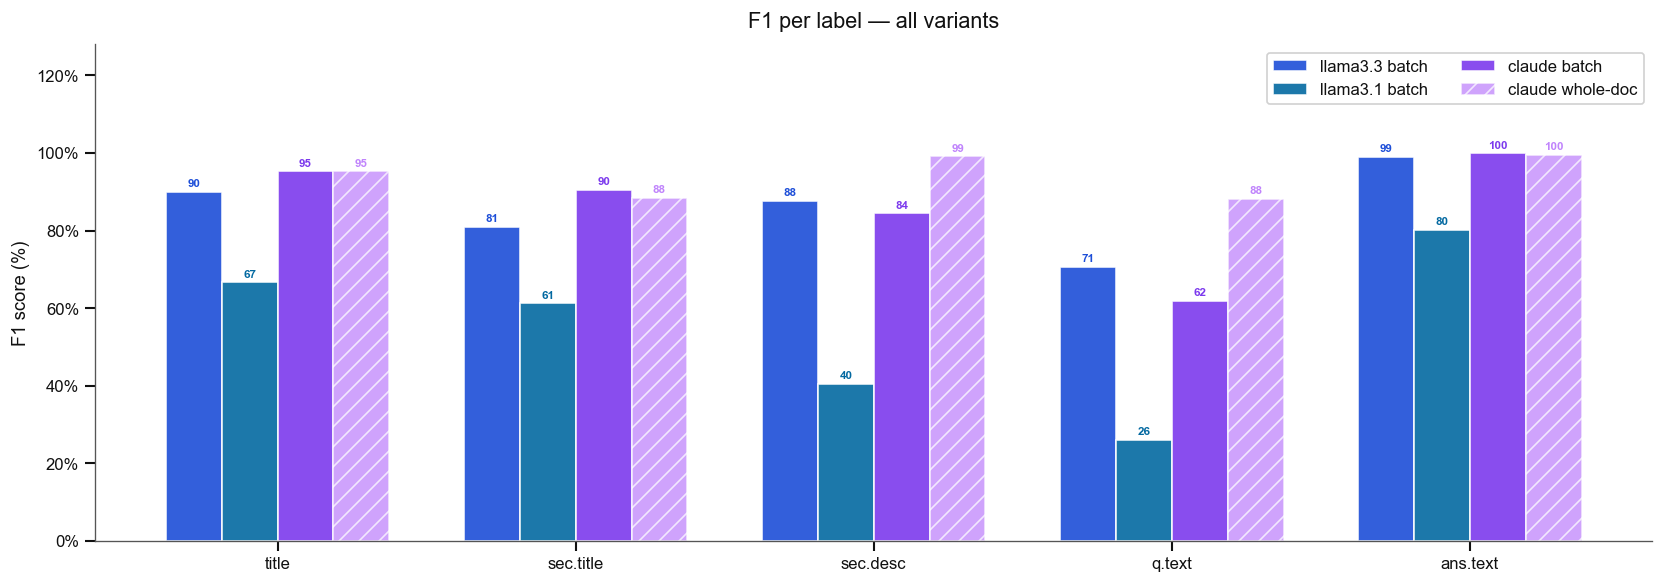


  Label                         llama3.3 batch        llama3.1 batch          claude batch      claude whole-doc
  --------------------------------------------------------------------------------------------------------------
  title                                  90.0%                 66.7%                 95.2%                 95.2%
  section.title                          80.9%                 61.3%                 90.5%                 88.4%
  section.description                    87.7%                 40.5%                 84.4%                 99.1%
  question.text                          70.7%                 26.1%                 62.0%                 88.2%
  answer.text                            99.0%                 80.2%                 99.9%                 99.6%


In [5]:
x2 = list(range(len(LABELS)))
w2 = 0.75 / n_v

fig, ax = plt.subplots(figsize=(14, 5))
for i, (name, (_, conf)) in enumerate(ACTIVE.items()):
    _, color, hatch = VARIANTS[name]
    alpha   = 0.9 if hatch is None else 0.75
    f1_vals = [_f1(conf, l) * 100 for l in LABELS]
    offset  = (i - n_v / 2 + 0.5) * w2
    bars    = ax.bar(
        [xi + offset for xi in x2], f1_vals,
        width=w2, label=name, color=color,
        edgecolor="white", alpha=alpha, hatch=hatch
    )
    for bar, v in zip(bars, f1_vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                    f"{v:.0f}", ha="center", va="bottom",
                    fontsize=7, fontweight="bold", color=color)

ax.set_xticks(x2)
ax.set_xticklabels(SHORT, fontsize=10)
ax.set_ylim(0, 128)
ax.set_ylabel("F1 score (%)")
ax.set_title("F1 per label — all variants", pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.legend(framealpha=0.9, ncol=2)
sns.despine()
plt.tight_layout()
plt.show()

# F1 table
print(f"\n  {'Label':<22}" + "".join(f"  {n:>20}" for n in ACTIVE))
print("  " + "-" * (22 + 22 * n_v))
for lbl in LABELS:
    row = f"  {lbl:<22}"
    for name, (_, conf) in ACTIVE.items():
        row += f"  {_f1(conf, lbl)*100:>19.1f}%"
    print(row)

## 4 — Claude batched vs whole-doc delta (core experiment)

For each of the 10 samples: how much does whole-doc context change accuracy?  
Green = improvement, red = regression. The dashed line is the overall mean delta.

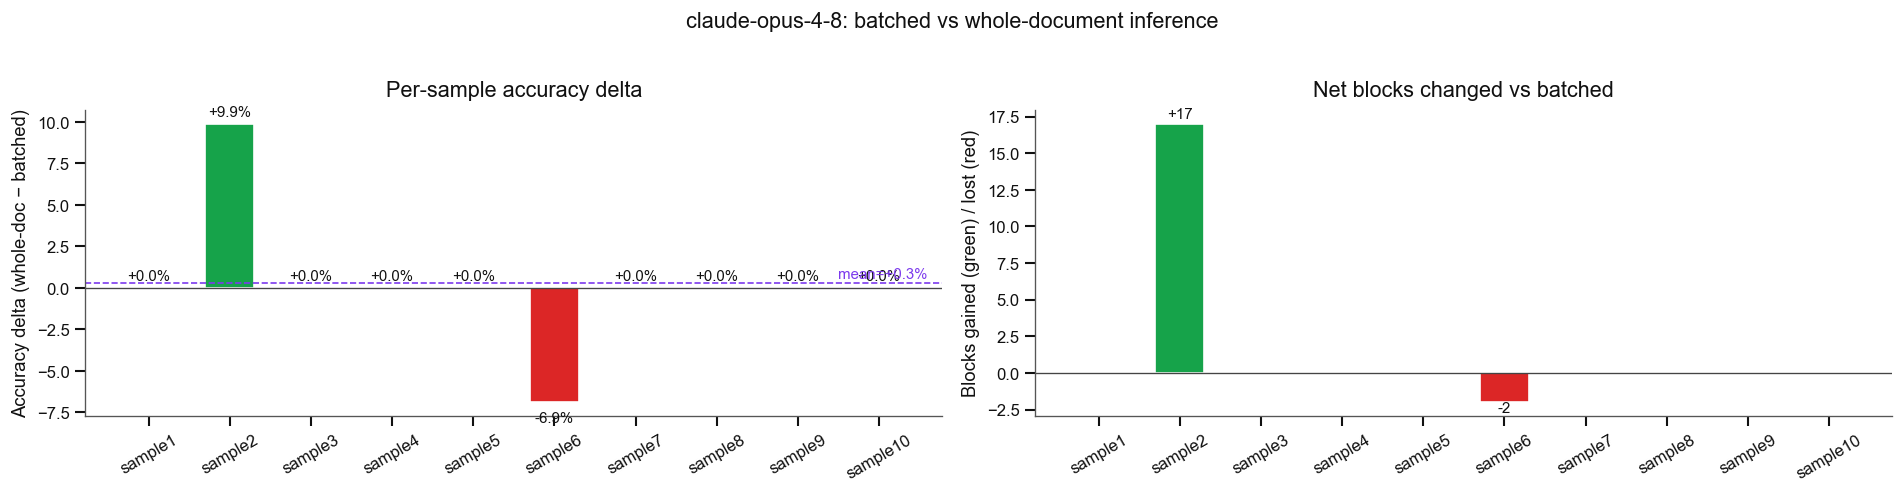


  Sample          Batched   Whole-doc     Delta   Net blocks
  ----------------------------------------------------------
  sample1          100.0%      100.0%  +    0.0%  +         0
  sample2           86.6%       96.5%  +    9.9%  +        17
  sample3          100.0%      100.0%  +    0.0%  +         0
  sample4          100.0%      100.0%  +    0.0%  +         0
  sample5           93.0%       93.0%  +    0.0%  +         0
  sample6           72.4%       65.5%     -6.9%          -2
  sample7           94.1%       94.1%  +    0.0%  +         0
  sample8          100.0%      100.0%  +    0.0%  +         0
  sample9          100.0%      100.0%  +    0.0%  +         0
  sample10         100.0%      100.0%  +    0.0%  +         0
  ----------------------------------------------------------
  OVERALL           94.9%       96.9%  +    2.0%  +        15


In [6]:
if "claude batch" not in ACTIVE or "claude whole-doc" not in ACTIVE:
    print("Claude whole-doc data not available — skipping delta analysis.")
else:
    df_b = ACTIVE["claude batch"][0]
    df_w = ACTIVE["claude whole-doc"][0]

    merged = (
        df_b[["sample", "accuracy", "correct", "total"]]
        .rename(columns={"accuracy": "acc_b", "correct": "cor_b", "total": "tot"})
        .merge(
            df_w[["sample", "accuracy", "correct"]]
            .rename(columns={"accuracy": "acc_w", "correct": "cor_w"}),
            on="sample"
        )
    )
    merged["delta"]  = merged["acc_w"] - merged["acc_b"]
    merged["gained"] = merged["cor_w"] - merged["cor_b"]
    merged = merged.sort_values("sample", key=lambda s: s.map(_snum))

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Left: accuracy delta
    ax = axes[0]
    colors_d = ["#16a34a" if d >= 0 else "#dc2626" for d in merged["delta"]]
    bars = ax.bar(merged["sample"], merged["delta"] * 100,
                  color=colors_d, edgecolor="white", width=0.6)
    for bar, d in zip(bars, merged["delta"] * 100):
        ypos = bar.get_height() + (0.3 if d >= 0 else -1.4)
        ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                f"{'+' if d>=0 else ''}{d:.1f}%",
                ha="center", va="bottom", fontsize=9)
    ax.axhline(0, color="#444", linewidth=0.8)
    avg = merged["delta"].mean() * 100
    ax.axhline(avg, color="#7c3aed", linestyle="--", linewidth=1)
    ax.text(len(merged) - 0.4, avg + 0.3,
            f"mean={avg:+.1f}%", ha="right", fontsize=9, color="#7c3aed")
    ax.set_ylabel("Accuracy delta (whole-doc − batched)")
    ax.set_title("Per-sample accuracy delta", pad=8)
    ax.tick_params(axis="x", rotation=30)
    sns.despine(ax=ax)

    # Right: net blocks changed
    ax = axes[1]
    colors_g = ["#16a34a" if g > 0 else ("#dc2626" if g < 0 else "#94a3b8")
                for g in merged["gained"]]
    ax.bar(merged["sample"], merged["gained"],
           color=colors_g, edgecolor="white", width=0.6)
    for xi, (_, r) in enumerate(merged.iterrows()):
        if r["gained"] != 0:
            ypos = r["gained"] + (0.2 if r["gained"] > 0 else -0.9)
            ax.text(xi, ypos,
                    f"{'+' if r['gained']>0 else ''}{int(r['gained'])}",
                    ha="center", va="bottom", fontsize=9)
    ax.axhline(0, color="#444", linewidth=0.8)
    ax.set_ylabel("Blocks gained (green) / lost (red)")
    ax.set_title("Net blocks changed vs batched", pad=8)
    ax.tick_params(axis="x", rotation=30)
    sns.despine(ax=ax)

    plt.suptitle("claude-opus-4-8: batched vs whole-document inference",
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    # Detail table
    print(f"\n  {'Sample':<12}  {'Batched':>9}  {'Whole-doc':>10}  {'Delta':>8}  {'Net blocks':>11}")
    print("  " + "-" * 58)
    for _, r in merged.iterrows():
        print(f"  {r['sample']:<12}  {r['acc_b']*100:>8.1f}%"
              f"  {r['acc_w']*100:>9.1f}%"
              f"  {'+' if r['delta']>=0 else ''}{r['delta']*100:>7.1f}%"
              f"  {'+' if r['gained']>=0 else ''}{int(r['gained']):>10}")
    print("  " + "-" * 58)
    tb = df_b["correct"].sum() / df_b["total"].sum()
    tw = df_w["correct"].sum() / df_w["total"].sum()
    net = int(df_w["correct"].sum() - df_b["correct"].sum())
    print(f"  {'OVERALL':<12}  {tb*100:>8.1f}%  {tw*100:>9.1f}%"
          f"  {'+' if (tw-tb)>=0 else ''}{(tw-tb)*100:>7.1f}%"
          f"  {'+' if net>=0 else ''}{net:>10}")

## 5 — Block-level gained / lost (all 10 samples)

For every block across all 10 samples, compare claude batch vs claude whole-doc against gold.  
**Gained** = whole-doc correct, batch wrong. **Lost** = whole-doc wrong, batch correct.  
The confusion breakdown shows *which label pair* the change involves.

In [7]:
if "claude batch" not in ACTIVE or "claude whole-doc" not in ACTIVE:
    print("Skipping block-level analysis — whole-doc data not available.")
else:
    block_rows = []
    for mp in SAMPLES:
        stem  = mp.stem.replace("_dmp", "")
        gold  = extract_gold(mp)
        pp_b  = LLM_DIR / f"{stem}_claude-opus-4-8.json"
        pp_w  = LLM_DIR / f"{stem}_claude-opus-4-8-wholedoc.json"
        if not (pp_b.exists() and pp_w.exists()): continue

        blocks_b = json.loads(pp_b.read_text(encoding="utf-8"))
        blocks_w = json.loads(pp_w.read_text(encoding="utf-8"))

        for i, (bb, bw) in enumerate(zip(blocks_b, blocks_w)):
            true_lbl = match(bb["text"], gold)
            if true_lbl is None: continue
            lb, lw = bb.get("label", "answer.text"), bw.get("label", "answer.text")
            block_rows.append({
                "sample":     stem,
                "block_id":   i,
                "page":       bb.get("page", "-"),
                "text":       bb["text"][:90],
                "gold":       true_lbl,
                "pred_batch": lb,
                "pred_whole": lw,
                "batch_ok":   lb == true_lbl,
                "whole_ok":   lw == true_lbl,
            })

    df_blk  = pd.DataFrame(block_rows)
    gained  = df_blk[ df_blk["whole_ok"] & ~df_blk["batch_ok"]]
    lost    = df_blk[~df_blk["whole_ok"] &  df_blk["batch_ok"]]

    print(f"Total matched blocks : {len(df_blk)}")
    print(f"Both correct         : {(df_blk['whole_ok'] & df_blk['batch_ok']).sum()}")
    print(f"Gained (whole-doc +) : {len(gained)} blocks")
    print(f"Lost   (whole-doc -) : {len(lost)} blocks")
    print(f"Both wrong           : {(~df_blk['whole_ok'] & ~df_blk['batch_ok']).sum()} blocks")
    print(f"Net change           : {len(gained)-len(lost):+d} blocks")

Total matched blocks : 726
Both correct         : 699
Gained (whole-doc +) : 19 blocks
Lost   (whole-doc -) : 4 blocks
Both wrong           : 4 blocks
Net change           : +15 blocks


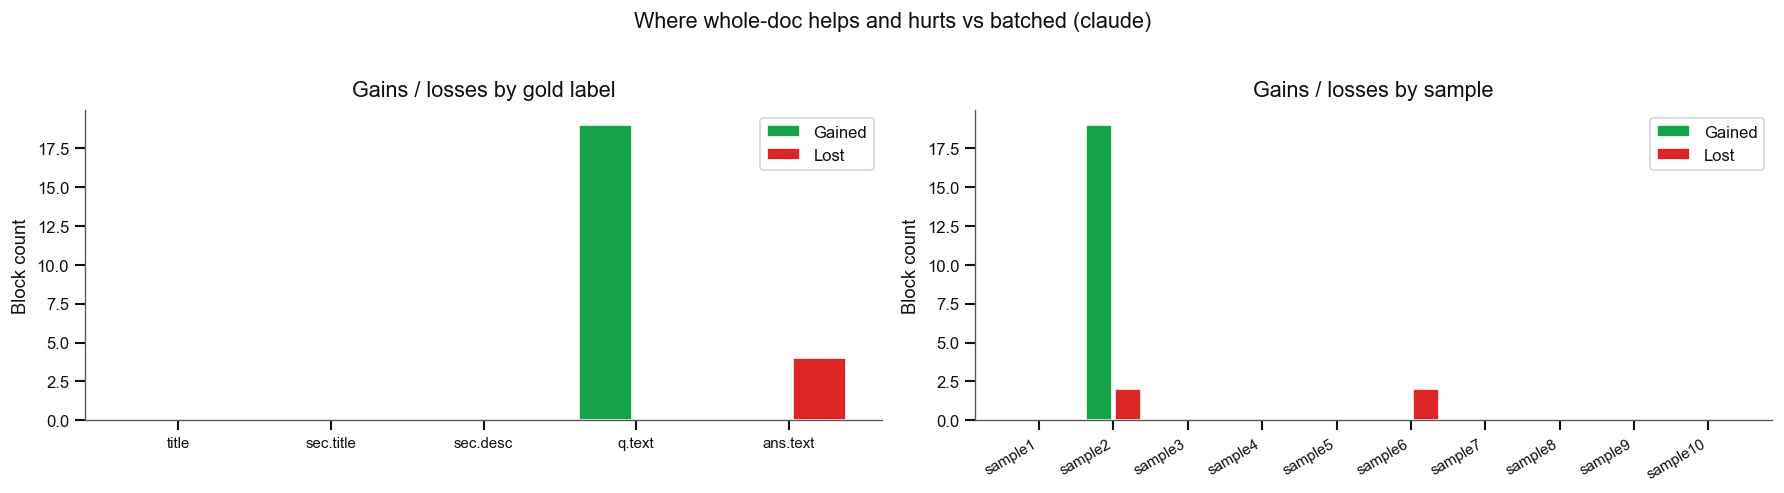


Gained blocks — error pattern batch introduced (gold → batch_pred, fixed by whole):
         gold          pred_batch  count
question.text section.description     19

Lost blocks — error pattern whole-doc introduced (gold → whole_pred):
       gold    pred_whole  count
answer.text question.text      2
answer.text section.title      2


In [8]:
if "df_blk" in dir() and len(df_blk) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    # Gains/losses by gold label
    ax = axes[0]
    lbl_gained = gained["gold"].value_counts().reindex(LABELS, fill_value=0)
    lbl_lost   = lost["gold"].value_counts().reindex(LABELS, fill_value=0)
    xi = list(range(len(LABELS)))
    ax.bar([i - 0.2 for i in xi], lbl_gained, width=0.35,
           label="Gained", color="#16a34a", edgecolor="white")
    ax.bar([i + 0.2 for i in xi], lbl_lost, width=0.35,
           label="Lost",   color="#dc2626", edgecolor="white")
    ax.set_xticks(xi); ax.set_xticklabels(SHORT, fontsize=9)
    ax.set_ylabel("Block count")
    ax.set_title("Gains / losses by gold label", pad=8)
    ax.legend(); sns.despine(ax=ax)

    # Gains/losses by sample
    ax = axes[1]
    samp_gained = gained["sample"].value_counts().reindex(SNAMES, fill_value=0)
    samp_lost   = lost["sample"].value_counts().reindex(SNAMES, fill_value=0)
    xi2 = list(range(len(SNAMES)))
    ax.bar([i - 0.2 for i in xi2], samp_gained, width=0.35,
           label="Gained", color="#16a34a", edgecolor="white")
    ax.bar([i + 0.2 for i in xi2], samp_lost, width=0.35,
           label="Lost",   color="#dc2626", edgecolor="white")
    ax.set_xticks(xi2); ax.set_xticklabels(SNAMES, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Block count")
    ax.set_title("Gains / losses by sample", pad=8)
    ax.legend(); sns.despine(ax=ax)

    plt.suptitle("Where whole-doc helps and hurts vs batched (claude)",
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    # Confusion shift
    print("\nGained blocks — error pattern batch introduced (gold → batch_pred, fixed by whole):")
    print(
        gained.groupby(["gold", "pred_batch"]).size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .to_string(index=False)
    )
    print("\nLost blocks — error pattern whole-doc introduced (gold → whole_pred):")
    print(
        lost.groupby(["gold", "pred_whole"]).size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .to_string(index=False)
    )

In [9]:
if "df_blk" in dir() and len(df_blk) > 0:
    pd.set_option("display.max_colwidth", 90)
    print(f"=== {len(gained)} GAINED blocks (whole-doc correct, batch wrong) ===")
    display(gained[["sample", "page", "gold", "pred_batch", "pred_whole", "text"]].reset_index(drop=True))

    print(f"\n=== {len(lost)} LOST blocks (whole-doc wrong, batch correct) ===")
    display(lost[["sample", "page", "gold", "pred_batch", "pred_whole", "text"]].reset_index(drop=True))

=== 19 GAINED blocks (whole-doc correct, batch wrong) ===


,sample,page,gold,pred_batch,pred_whole,text
0,sample2,2,question.text,section.description,question.text,"This should include, where appropriate:"
1,sample2,2,question.text,section.description,question.text,the anticipated means for sharing and rationale for any restrictions on who may access...
2,sample2,2,question.text,section.description,question.text,and under what conditions;
3,sample2,2,question.text,section.description,question.text,a timeline for sharing and preservation that addresses both the minimum length of time...
4,sample2,2,question.text,section.description,question.text,will be available and any anticipated delay to data access after research findings are...
5,sample2,2,question.text,section.description,question.text,"any special requirements for data sharing, for example, proprietary software needed to..."
6,sample2,2,question.text,section.description,question.text,"or interpret data, applicable policies, provisions, and licenses for re-use and re-dis..."
7,sample2,2,question.text,section.description,question.text,"for the production of derivatives, including guidance for how data and data products s..."
8,sample2,2,question.text,section.description,question.text,cited;
9,sample2,2,question.text,section.description,question.text,"any resources and capabilities (equipment, connections, systems, software, expertise, ..."



=== 4 LOST blocks (whole-doc wrong, batch correct) ===


,sample,page,gold,pred_batch,pred_whole,text
0,sample2,1,answer.text,answer.text,question.text,"Roles & Responsibilities. For the proposed research, Director Samuel Stupp with help f..."
1,sample2,4,answer.text,answer.text,question.text,"Data Volume. Generally, the volume of data generated by CBES researchers should not pr..."
2,sample6,1,answer.text,answer.text,section.title,"1. Types of data. The bulk of the data generated in this project will be 1, 2, 3, and 4"
3,sample6,1,answer.text,answer.text,section.title,3. Policies for access and sharing. Interested parties will be able to request data an...


## 6 — Summary

In [10]:
print("=" * 65)
print("  Experiment 01 — Whole-doc vs Batched  (10 samples)")
print("=" * 65)

for name, (df, conf) in ACTIVE.items():
    tc, tn = int(df["correct"].sum()), int(df["total"].sum())
    f1_qt  = _f1(conf, "question.text")       * 100
    f1_sd  = _f1(conf, "section.description") * 100
    print(f"  {name:<22}  {tc/tn*100:.1f}%  "
          f"q.text={f1_qt:.1f}%  sec.desc={f1_sd:.1f}%")

if "df_blk" in dir() and len(df_blk) > 0:
    print()
    print(f"  Whole-doc gained : {len(gained)} blocks  "
          f"(across {gained['sample'].nunique()} samples)")
    print(f"  Whole-doc lost   : {len(lost)} blocks  "
          f"(across {lost['sample'].nunique()} samples)")
    print(f"  Net improvement  : {len(gained)-len(lost):+d} blocks")

    if len(gained):
        top_gain = gained["gold"].value_counts().index[0]
        print(f"  Most-gained label: {top_gain}")
    if len(lost):
        top_loss = lost["gold"].value_counts().index[0]
        print(f"  Most-lost label  : {top_loss}")

    best   = merged.set_index("sample")["delta"].idxmax()
    worst  = merged.set_index("sample")["delta"].idxmin()
    best_d  = merged.set_index("sample").loc[best,  "delta"] * 100
    worst_d = merged.set_index("sample").loc[worst, "delta"] * 100
    print(f"  Best sample      : {best}  ({best_d:+.1f}%)")
    print(f"  Worst regression : {worst}  ({worst_d:+.1f}%)")

print("=" * 65)
print()
print("Next steps:")
print("  - Run `python run_wholedoc_ollama.py --model llama3.3:70b` to add llama whole-doc data")
print("  - Investigate regression sample to understand where whole-doc hurts")
print("  - Consider hybrid: whole-doc for question.text, batched for answer.text")

  Experiment 01 — Whole-doc vs Batched  (10 samples)
  llama3.3 batch          94.1%  q.text=70.7%  sec.desc=87.7%
  llama3.1 batch          67.3%  q.text=26.1%  sec.desc=40.5%
  claude batch            94.9%  q.text=62.0%  sec.desc=84.4%
  claude whole-doc        96.9%  q.text=88.2%  sec.desc=99.1%

  Whole-doc gained : 19 blocks  (across 1 samples)
  Whole-doc lost   : 4 blocks  (across 2 samples)
  Net improvement  : +15 blocks
  Most-gained label: question.text
  Most-lost label  : answer.text
  Best sample      : sample2  (+9.9%)
  Worst regression : sample6  (-6.9%)

Next steps:
  - Run `python run_wholedoc_ollama.py --model llama3.3:70b` to add llama whole-doc data
  - Investigate regression sample to understand where whole-doc hurts
  - Consider hybrid: whole-doc for question.text, batched for answer.text
